In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("marketing_campaign.csv", sep=",")


def label_encode(column):
    unique_values = list(pd.unique(column))
    mapping = {value: index for index, value in enumerate(unique_values)}
    encoded = column.map(mapping)
    return encoded, mapping


def one_hot_encode(column):
    unique_values = list(pd.unique(column))
    encoded = pd.DataFrame()

    for value in unique_values:
        encoded[str(column.name) + "_" + str(value)] = (column == value).astype(int)

    return encoded

In [ ]:
encoded_df = df.copy()

categorical_columns = encoded_df.select_dtypes(include=["object"]).columns.tolist()

if "Dt_Customer" in categorical_columns:
    categorical_columns.remove("Dt_Customer")

for column in categorical_columns:
    encoded_df[column], _ = label_encode(encoded_df[column])

print("Original Dataset Shape :", df.shape)
print("Label Encoded Shape    :", encoded_df.shape)

one_hot_df = df.copy()

for column in categorical_columns:
    encoded_columns = one_hot_encode(one_hot_df[column])
    one_hot_df = one_hot_df.drop(column, axis=1)
    one_hot_df = pd.concat([one_hot_df, encoded_columns], axis=1)

print("One-Hot Encoded Shape  :", one_hot_df.shape)

print("\nCategorical Columns:")
print(categorical_columns)

print("\nLabel Encoded Dataset (First 5 Rows)")
print(encoded_df.head())

print("\nOne-Hot Encoded Dataset (First 5 Rows)")
print(one_hot_df.head())

Original Dataset Shape : (2240, 29)
Label Encoded Shape    : (2240, 29)
One-Hot Encoded Shape  : (2240, 40)

Categorical Columns:
['Education', 'Marital_Status']

Label Encoded Dataset (First 5 Rows)
     ID  Year_Birth  Education  Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957          0               0  58138.0        0         0   
1  2174        1954          0               0  46344.0        1         1   
2  4141        1965          0               1  71613.0        0         0   
3  6182        1984          0               1  26646.0        1         0   
4  5324        1981          1               2  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0    4/9/2012       58       635  ...                  7             0   
1    8/3/2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3   10/2/2014       26        11  .

In [ ]:
def minkowski_distance(vector1, vector2, p):
    vector1 = np.array(vector1, dtype=float)
    vector2 = np.array(vector2, dtype=float)

    distance = np.sum(np.abs(vector1 - vector2) ** p) ** (1 / p)

    return distance

Minkowski Distance Values
p = 1: 16781.0000
p = 2: 12290.3712
p = 3: 11884.3746
p = 4: 11813.1821
p = 5: 11798.3595
p = 6: 11795.0321
p = 7: 11794.2513
p = 8: 11794.0625
p = 9: 11794.0158
p = 10: 11794.0040


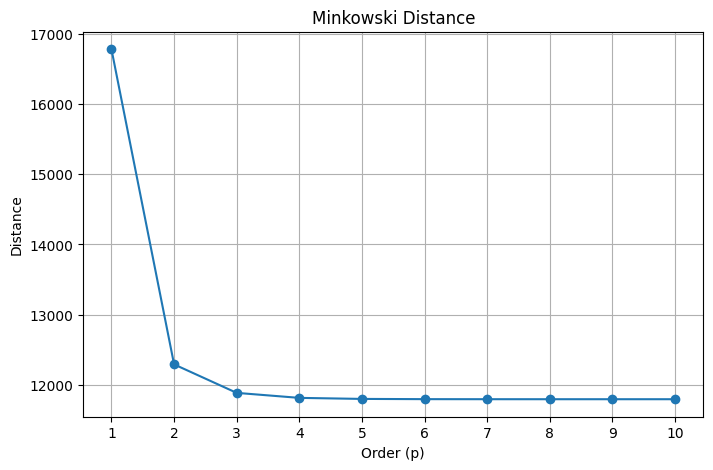

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

numeric_df = encoded_df.select_dtypes(include=np.number)

vector1 = numeric_df.iloc[0].to_numpy(dtype=float)
vector2 = numeric_df.iloc[1].to_numpy(dtype=float)

p_values = list(range(1, 11))
distances = []

for p in p_values:
    distances.append(minkowski_distance(vector1, vector2, p))

print("Minkowski Distance Values")
for p, d in zip(p_values, distances):
    print(f"p = {p}: {d:.4f}")

plt.figure(figsize=(8,5))
plt.plot(p_values, distances, marker='o')
plt.xticks(p_values)
plt.xlabel("Order (p)")
plt.ylabel("Distance")
plt.title("Minkowski Distance")
plt.grid(True)
plt.show()

In [ ]:
from scipy.spatial.distance import minkowski
import pandas as pd

results = []

for p in range(1, 11):
    own = minkowski_distance(vector1, vector2, p)
    scipy_result = minkowski(vector1, vector2, p)
    results.append([p, own, scipy_result])

comparison = pd.DataFrame(
    results,
    columns=["p", "Own Function", "Scipy Function"]
)

print(comparison)

    p  Own Function  Scipy Function
0   1  16781.000000    16781.000000
1   2  12290.371231    12290.371231
2   3  11884.374554    11884.374554
3   4  11813.182057    11813.182057
4   5  11798.359466    11798.359466
5   6  11795.032150    11795.032150
6   7  11794.251319    11794.251319
7   8  11794.062465    11794.062465
8   9  11794.015771    11794.015771
9  10  11794.004032    11794.004032


In [ ]:
import numpy as np

def dot_product(a, b):
    total = 0
    for x, y in zip(a, b):
        total += x * y
    return total


def euclidean_norm(a):
    total = 0
    for value in a:
        total += value ** 2
    return total ** 0.5

In [ ]:
own_dot = dot_product(vector1, vector2)
numpy_dot = np.dot(vector1, vector2)

own_norm1 = euclidean_norm(vector1)
own_norm2 = euclidean_norm(vector2)

numpy_norm1 = np.linalg.norm(vector1)
numpy_norm2 = np.linalg.norm(vector2)

print("Dot Product")
print("Own Function :", own_dot)
print("NumPy        :", numpy_dot)

print()

print("Vector 1 Euclidean Norm")
print("Own Function :", own_norm1)
print("NumPy        :", numpy_norm1)

print()

print("Vector 2 Euclidean Norm")
print("Own Function :", own_norm2)
print("NumPy        :", numpy_norm2)

Dot Product
Own Function : 2710194336.0
NumPy        : 2710194336.0

Vector 1 Euclidean Norm
Own Function : 58439.10812974476
NumPy        : 58439.10812974476

Vector 2 Euclidean Norm
Own Function : 46436.11243418208
NumPy        : 46436.11243418208


In [ ]:
import numpy as np

def calculate_mean(values):
    return sum(values) / len(values)


def calculate_variance(values):
    mean = calculate_mean(values)
    total = 0

    for value in values:
        total += (value - mean) ** 2

    return total / len(values)


def calculate_std(values):
    return calculate_variance(values) ** 0.5


def dataset_statistics(matrix):
    means = []
    variances = []
    stds = []

    matrix = np.array(matrix)

    for i in range(matrix.shape[1]):
        column = matrix[:, i]
        means.append(calculate_mean(column))
        variances.append(calculate_variance(column))
        stds.append(calculate_std(column))

    return means, variances, stds

In [ ]:
matrix = numeric_df.to_numpy(dtype=float)

means, variances, stds = dataset_statistics(matrix)

numpy_mean = np.mean(matrix, axis=0)
numpy_std = np.std(matrix, axis=0)

comparison = pd.DataFrame({
    "Feature": numeric_df.columns,
    "Own Mean": means,
    "NumPy Mean": numpy_mean,
    "Own Std": stds,
    "NumPy Std": numpy_std
})

print(comparison)

                Feature     Own Mean   NumPy Mean      Own Std    NumPy Std
0                    ID  5592.159821  5592.159821  3245.937415  3245.937415
1            Year_Birth  1968.805804  1968.805804    11.981394    11.981394
2             Education     0.982143     0.982143     1.256996     1.256996
3        Marital_Status     1.496875     1.496875     1.073624     1.073624
4                Income          NaN          NaN          NaN          NaN
5               Kidhome     0.444196     0.444196     0.538278     0.538278
6              Teenhome     0.506250     0.506250     0.544417     0.544417
7               Recency    49.109375    49.109375    28.955987    28.955987
8              MntWines   303.935714   303.935714   336.522251   336.522251
9             MntFruits    26.302232    26.302232    39.764555    39.764555
10      MntMeatProducts   166.950000   166.950000   225.664984   225.664984
11      MntFishProducts    37.525446    37.525446    54.616784    54.616784
12     MntSw

Feature : Income
Mean : nan
Variance : nan


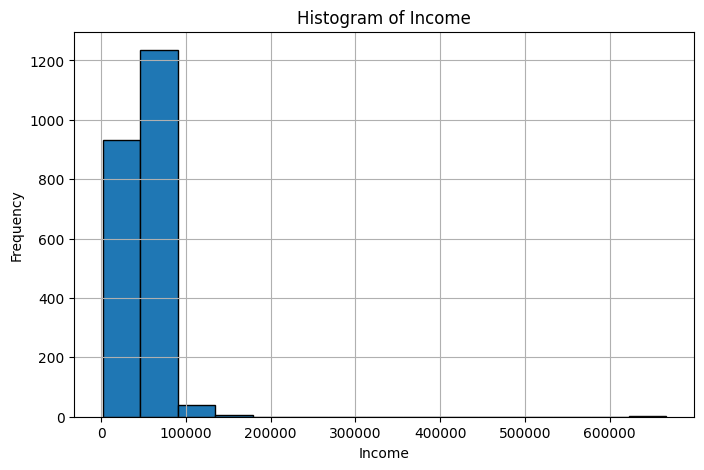

In [ ]:
feature = "Income"

values = numeric_df[feature]

mean_value = calculate_mean(values)
variance_value = calculate_variance(values)

print("Feature :", feature)
print("Mean :", mean_value)
print("Variance :", variance_value)

plt.figure(figsize=(8,5))
plt.hist(values, bins=15, edgecolor="black")
plt.xlabel(feature)
plt.ylabel("Frequency")
plt.title("Histogram of " + feature)
plt.grid(True)
plt.show()